# K-Means Clustering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/01-unsupervised-learning/k-means/notes.ipynb)

**Module:** Unsupervised Learning
**Sources:** class pre-read doc, class notes site, class Colab notebook (ClusterMart session)


## Session overview

> *"You're going to invent an algorithm yourself before we ever write a line of K-Means code — that's the whole point of this session."*

The session builds up in this order, and these notes follow the same order:

| # | What's covered | Why it matters |
|---|---|---|
| 01 | Why supervised learning breaks down | ClusterMart wants customer segments, but there's no "Premium" or "Discount Hunter" label anywhere in the data — every supervised technique hits a wall here. That gap is what clustering exists to fill. |
| 02 | Measuring "similarity" with distance | Before any algorithm can group points, it needs a precise definition of "close" — formalized with Euclidean distance. |
| 03 | What makes a clustering good or bad | Vocabulary for *intra-* vs *inter-cluster* distance — this sets up the exact objective K-Means optimizes. |
| 04 | Inventing & coding K-Means from scratch | Derive the algorithm step by step, then implement initialize → assign → update → fit in raw NumPy. |
| 05 | Choosing K & judging cluster quality | K-Means won't tell you how many clusters to use — the Elbow Method and Silhouette Score back that choice with numbers. |
| 06 | Building ClusterMart's real segmentation engine | Scaling features, running the full pipeline, and translating raw clusters into segments marketing can act on. |

**Walk-away goal:** explain why unlabeled data needs a different toolkit than supervised learning, derive K-Means from first principles instead of memorizing it, implement it end-to-end in NumPy, and defend a choice of K using the elbow method + silhouette score.

> *"You didn't learn K-Means today — you invented it, then wrote the code to prove yourself right."*


## 1. Why supervised learning breaks down

**The business problem:** ClusterMart has millions of customers and zero labels. They want customer segments —
"Premium", "Discount Hunter", "Frequent Buyer" — but nobody has ever tagged a single customer with one of these
labels. Supervised learning needs a target column (`y`) to learn from; here, there isn't one.

**Framing:** Supervised learning requires labeled target values to learn from. In customer segmentation, the goal
is to *discover* hidden groups in unlabeled data — which is exactly what unsupervised learning methods like
K-Means are built for.

**Clustering, defined:** grouping data points so that points in the same group are more similar to each other than
to points in other groups — using only the raw features, no labels required.

**Other places clustering shows up:**
- Playlists — grouping listeners with similar taste
- Watch history — grouping viewers by streaming behavior
- Photo albums — automatically grouping photos of the same person
- Image compression — grouping similar pixel colors


## 2. Measuring "similarity" with distance

Before any algorithm can group points, it needs a precise definition of "close." K-Means formalizes this with
**Euclidean distance**:

$$
d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \cdots + (p_n - q_n)^2}
$$

i.e. `np.linalg.norm(p - q)` for two points `p` and `q`. This is the building block everything else stands on —
"close" now has a number attached to it.


In [1]:
import numpy as np

def euclidean_distance(p, q):
    """Straight-line distance between two points (any number of dimensions)."""
    return np.linalg.norm(np.array(p) - np.array(q))

# sanity check
euclidean_distance([0, 0], [3, 4])  # -> 5.0

np.float64(5.0)

## 3. What makes a clustering good or bad

Two analysts can submit two different groupings of the same data — only one is actually good. The vocabulary that
tells them apart:

- **Intra-cluster distance** — how spread out points are *within* the same cluster. Smaller means tighter, more
  cohesive groups.
- **Inter-cluster distance** — how far apart *different* clusters sit from each other. Larger means more distinct,
  separable groups.

A good clustering minimizes intra-cluster distance while keeping inter-cluster distance large. K-Means formalizes
the "minimize intra-cluster spread" half of this directly as its objective:

**Within-Cluster Sum of Squares (WCSS / inertia):**

$$
WCSS = \sum_{i=1}^{k} \sum_{p \in C_i} \lVert p - \mu_i \rVert^2
$$

— the total squared distance from each point to its own cluster's centroid $\mu_i$. This is exactly the number
K-Means tries to minimize.


## 4. Inventing & coding K-Means from scratch

If you were asked to automate clustering yourself, step by step, you'd likely land on this exact loop:

1. **Initialize** — pick `k` starting center points (centroids).
2. **Assign** — allocate every point to its nearest centroid.
3. **Update** — move each centroid to the mean position of the points assigned to it.
4. **Repeat** — keep alternating assign/update until the centroids stop moving (convergence).

**Why the mean?** The mean is the single point that minimizes WCSS for a set of points — which is exactly why
K-Means' update step moves each centroid there. It's not an arbitrary choice; it's the mathematically optimal one
for this objective.

Below is the from-scratch implementation exactly as built in class, one building block at a time.


### 4.1 Initialize — pick starting centroids

In [2]:
def initialize_centroids(X, k, seed=100):
    """Randomly pick k data points to serve as the starting centroids."""
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(X), size=k, replace=False)
    print("Indices:",indices)
    return X[indices].copy()

### 4.2 Assign — allocate every point to its nearest centroid

In [3]:
#Assignment of clusters to each datapoint
def assign_clusters(X, centroids):
    labels = []

    for point in X:
        # Calculate distance from this point to every centroid
        distances = []

        for centroid in centroids:
            distance = np.linalg.norm(point - centroid)
            distances.append(distance)

        # Assign the point to the nearest centroid
        labels.append(np.argmin(distances))

    return np.array(labels)

### 4.3 Update — move each centroid to the mean of its assigned points

In [4]:
def update_centroids(X, labels, centroids):
    new_centroids = []

    for i in range(len(centroids)):
        cluster = X[labels == i]

        if len(cluster) == 0:
            # keep old centroid
            new_centroids.append(centroids[i])
        else:
            new_centroids.append(cluster.mean(axis=0))

    return np.array(new_centroids)
print("Building blocks defined.")

Building blocks defined.


### 4.4 Fit — put initialize / assign / update together into the full loop

This also plots every iteration side by side, so you can *watch* the centroids converge.

In [5]:
def fit(X, k, n_iters=100, seed=42, plot_every=False):
    centroids = initialize_centroids(X, k, seed)

    if plot_every:
        plot_states = [] # List to store (labels, new_centroids, iteration_number) tuples

    for i in range(n_iters):
        # Store centroids before assignment step to match original convergence check logic
        centroids_before_assignment = centroids.copy()

        # Step 1: Assign points
        labels = assign_clusters(X, centroids_before_assignment)

        # Step 2: Compute new centroids
        new_centroids = update_centroids(X, labels, centroids_before_assignment)

        # Store the state for plotting if plot_every is True
        if plot_every:
            # We want to plot `labels` (assigned by centroids_before_assignment) and `new_centroids`
            plot_states.append((labels.copy(), new_centroids.copy(), i + 1))

        # Check convergence
        if np.linalg.norm(new_centroids - centroids_before_assignment) < 1e-5:
            print(f"Converged after {i+1} iterations.")
            centroids = new_centroids # Update `centroids` for the function's return value
            break # Exit the loop, the last state is already in plot_states

        centroids = new_centroids # Update `centroids` for the next iteration

    # Final assignment of labels after the loop, based on the final `centroids`
    labels = assign_clusters(X, centroids)

    # Now, generate all plots horizontally if plot_every is True
    if plot_every and plot_states:
        num_plots = len(plot_states)
        # Ensure that if only one plot is generated, axes is still an iterable (1D array)
        fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4), squeeze=False)
        axes = axes.flatten()

        for idx, (iter_labels, iter_centroids, iter_num) in enumerate(plot_states):
            ax = axes[idx]
            for j in range(k):
                ax.scatter(
                    X[iter_labels == j, 0],
                    X[iter_labels == j, 1],
                    s=20,
                    label=f"Cluster {j}" if idx == 0 else "" # Label only for the first subplot
                )
            ax.scatter(
                iter_centroids[:, 0],
                iter_centroids[:, 1],
                marker="X",
                s=180,
                c="black",
                label="Centroids" if idx == 0 else "" # Label only for the first subplot
            )
            ax.set_title(f"Iteration {iter_num}")
            ax.set_xticks([])
            ax.set_yticks([])
            if idx == 0:
                ax.legend(loc='lower right') # Legend only for the first subplot
        plt.tight_layout()
        plt.show()

    return centroids, labels

### 4.5 Run it

Indices: [128  18 130 105]
Converged after 4 iterations.


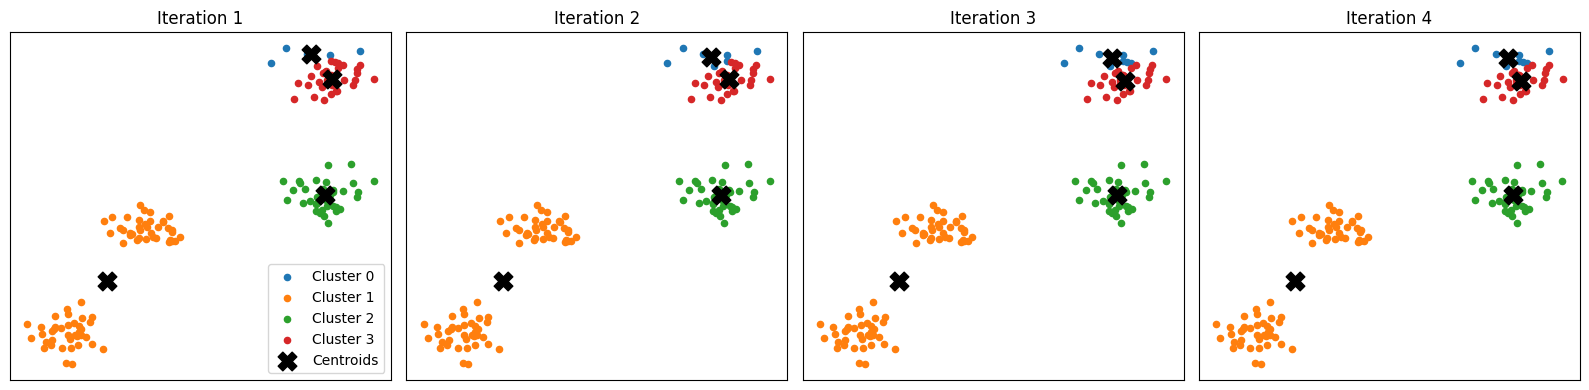

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Run our from-scratch K-Means
X_scratch, _ = make_blobs(
    n_samples=150,
    centers=4,
    cluster_std=0.9,
    random_state=8
)
centroids_scratch, labels_scratch = fit(
    X_scratch,
    k=4,
    seed=4,
    plot_every=True
)

### 4.6 Sanity check against scikit-learn
Same data, same idea — confirms the from-scratch version lands in the same place as the library implementation.

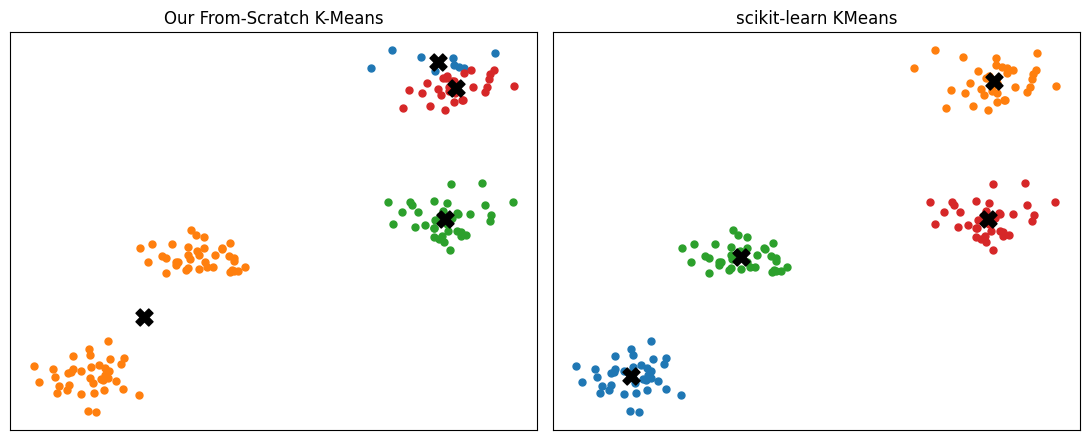

In [7]:
from sklearn.cluster import KMeans

# Compare our from-scratch implementation against scikit-learn's KMeans
sk_model = KMeans(
    n_clusters=4,
    init="random",
    n_init=1,
    random_state=42
)
sk_labels = sk_model.fit_predict(X_scratch)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for j in range(4):
    axes[0].scatter(X_scratch[labels_scratch == j, 0], X_scratch[labels_scratch == j, 1], s=25)
    axes[1].scatter(X_scratch[sk_labels == j, 0], X_scratch[sk_labels == j, 1], s=25)
axes[0].scatter(centroids_scratch[:, 0], centroids_scratch[:, 1], marker='X', s=150, c='black')
axes[1].scatter(sk_model.cluster_centers_[:, 0], sk_model.cluster_centers_[:, 1], marker='X', s=150, c='black')
axes[0].set_title("Our From-Scratch K-Means")
axes[1].set_title("scikit-learn KMeans")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

> **Note on initialization:** starting from different random centers can converge to different final groupings
> on the same data — this is why `scikit-learn` defaults to `k-means++` (smarter initialization) and `n_init > 1`
> (multiple random restarts, keeping the best result) rather than one plain random start.


## 5. Choosing K & judging cluster quality

K-Means won't tell you how many clusters to use — you have to decide, and back that choice with numbers rather
than a guess. Two methods, used together:

**The Elbow Method** — plot WCSS against K. WCSS decreases monotonically as K increases (more clusters can only
reduce spread), so look for the point of *diminishing returns*: the "elbow" where adding clusters stops buying
much improvement.

**The Silhouette Score** — for a point, compares its average distance to its own cluster ($a$) against its average
distance to the nearest *other* cluster ($b$):

$$
s = \frac{b - a}{\max(a, b)}
$$

Ranges from −1 to +1:
- **Close to +1** — well-clustered, far from other clusters.
- **Close to 0** — sitting right on a cluster border.
- **Negative** — likely misassigned to the wrong cluster.

Neither method alone gives a perfect answer for K — both should inform the decision together.


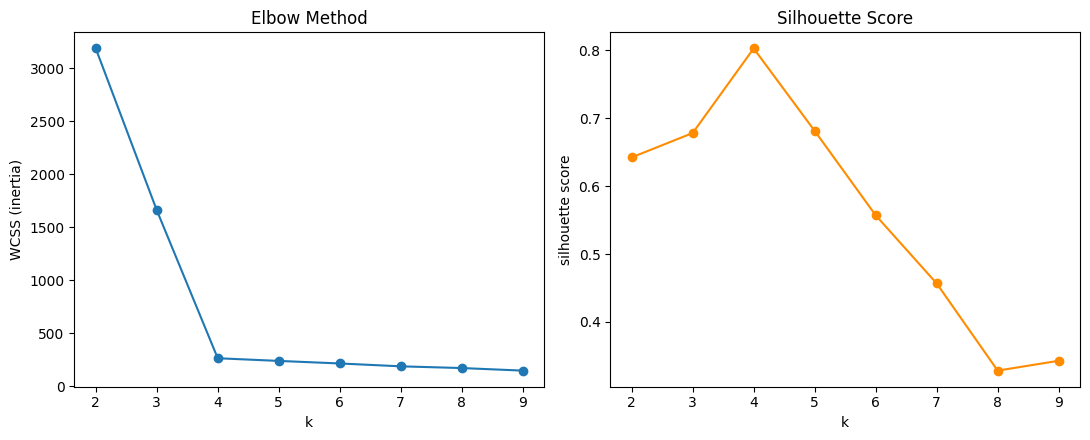

In [8]:
from sklearn.metrics import silhouette_score

wcss = []
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scratch)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scratch, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(list(k_range), wcss, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k"); axes[0].set_ylabel("WCSS (inertia)")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette score")
plt.tight_layout()
plt.show()

## 6. Applied: ClusterMart's real segmentation engine

Everything comes together on ClusterMart's (simulated) customer data: `annual_spend`, `purchase_frequency`,
`discount_usage_pct`.

**Feature scaling — why it's required first:** distance-based algorithms like K-Means let large-scale features
dominate the distance calculation. `annual_spend` ranges into the thousands while `discount_usage_pct` ranges
0–100 — left unscaled, spend alone would decide the clusters. Standardizing (`StandardScaler`) puts every feature
on the same footing (mean 0, std 1) before clustering:

| Feature | Raw mean → scaled | Raw std → scaled |
|---|---|---|
| `annual_spend` | 3471.8 → 0.0 | 2824.1 → 1.0 |
| `purchase_frequency` | 20.3 → 0.0 | 12.7 → 1.0 |
| `discount_usage_pct` | 30.8 → 0.0 | 24.6 → 1.0 |

**Result — K=4 was chosen** (elbow appears around K=4, silhouette scores stayed strong while still capturing
natural structure in the data). The four segments that came out:

| Segment | Annual spend | Purchase frequency | Discount usage | Count |
|---|---|---|---|---|
| Occasional Visitors | \$588.10 | 3.4/yr | 29.3% | 92 |
| Frequent Buyers | \$3,564.10 | 34.7/yr | 19.4% | 100 |
| Discount Hunters | \$1,736.60 | 14.1/yr | 66.4% | 108 |
| Premium Customers | \$7,906.50 | 28.1/yr | 5.3% | 100 |

**Turning clusters into business decisions** — clusters only become useful once translated into segments
marketing can actually act on:
- **Premium Customers** → VIP loyalty perks, early product access
- **Frequent Buyers** → subscribe & save, bundle deals
- **Discount Hunters** → flash sales, coupon campaigns
- **Occasional Visitors** → re-engagement campaigns, win-back offers

Below, a simulated version of this pipeline end-to-end — generating similar customer data, scaling it, fitting
K-Means, and visualizing the resulting segments (this part isn't from the class Colab notebook directly; it's a
runnable reconstruction of the case study above so the numbers stay hands-on rather than just a table).


In [9]:
import pandas as pd

rng = np.random.default_rng(7)

def make_segment(n, spend_mean, spend_std, freq_mean, freq_std, disc_mean, disc_std):
    return pd.DataFrame({
        "annual_spend": rng.normal(spend_mean, spend_std, n).clip(min=0),
        "purchase_frequency": rng.normal(freq_mean, freq_std, n).clip(min=0),
        "discount_usage_pct": rng.normal(disc_mean, disc_std, n).clip(0, 100),
    })

customers = pd.concat([
    make_segment(92,  588.10,  200, 3.4,  1.5, 29.3, 10),   # Occasional Visitors
    make_segment(100, 3564.10, 700, 34.7, 6.0, 19.4, 8),    # Frequent Buyers
    make_segment(108, 1736.60, 500, 14.1, 4.0, 66.4, 12),   # Discount Hunters
    make_segment(100, 7906.50, 1200, 28.1, 5.0, 5.3, 4),    # Premium Customers
], ignore_index=True)

customers.describe()

,annual_spend,purchase_frequency,discount_usage_pct
count,400.000000,400.000000,400.000000
mean,3523.749000,19.778163,29.835973
std,2929.914541,12.437918,24.556686
min,84.748058,0.207149,0.000000
25%,1070.843593,7.630335,8.706025
50%,2518.472106,20.333673,21.375767
75%,5157.159355,30.001656,49.687625
max,10681.885658,49.921577,97.260027


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_customers = scaler.fit_transform(customers)

km_customers = KMeans(n_clusters=4, n_init=10, random_state=42)
customers["segment"] = km_customers.fit_predict(X_customers)

customers.groupby("segment")[["annual_spend", "purchase_frequency", "discount_usage_pct"]].mean().round(1)

,annual_spend,purchase_frequency,discount_usage_pct
segment,,,
0,3619.9,33.4,17.1
1,1760.2,14.2,65.5
2,570.2,3.1,28.7
3,8152.0,27.5,5.3


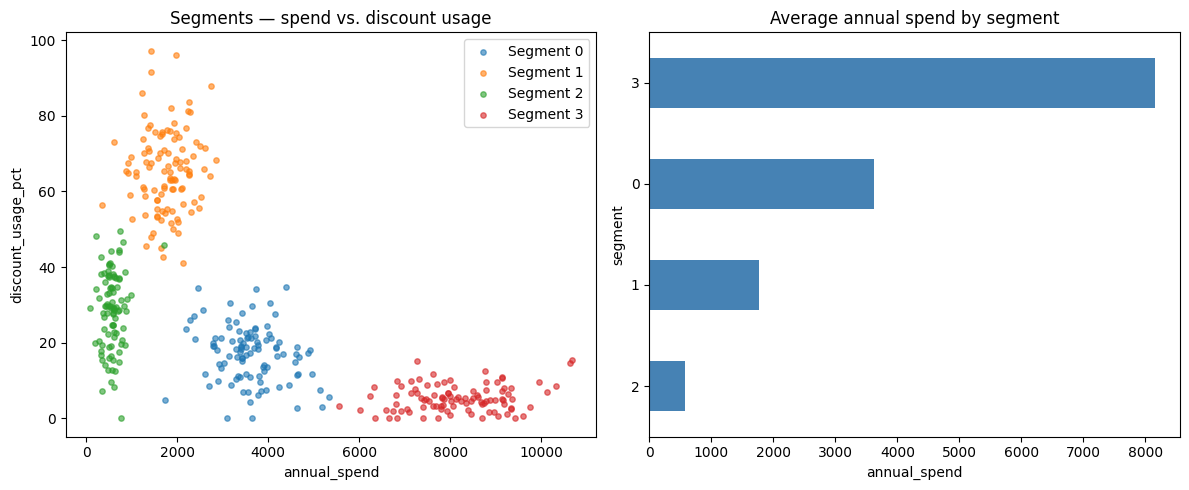

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for seg in sorted(customers["segment"].unique()):
    subset = customers[customers["segment"] == seg]
    axes[0].scatter(subset["annual_spend"], subset["discount_usage_pct"], s=15, alpha=0.6, label=f"Segment {seg}")

axes[0].set_xlabel("annual_spend"); axes[0].set_ylabel("discount_usage_pct")
axes[0].set_title("Segments — spend vs. discount usage")
axes[0].legend()

customers.groupby("segment")["annual_spend"].mean().sort_values().plot(
    kind="barh", ax=axes[1], color="steelblue"
)
axes[1].set_title("Average annual spend by segment")
axes[1].set_xlabel("annual_spend")

plt.tight_layout()
plt.show()

## 7. Limitations of K-Means

K-Means carries specific assumptions that can break down:

1. **Spherical clusters** — it can't represent curved or elongated cluster shapes.
2. **Similar cluster sizes** — imbalanced group sizes distort the mean-based centroids.
3. **Euclidean distance validity** — breaks down for categorical data, or data that's naturally circular/angular.
4. **Outlier sensitivity** — extreme points drag centroids away from the "true" center of a cluster.
5. **Initialization sensitivity** — different random starting centroids can converge to different final groupings
   on the same data (mitigated by `k-means++` init + multiple restarts via `n_init`).

When these assumptions don't hold, other algorithms (DBSCAN for non-spherical/noisy clusters, hierarchical
clustering when you don't want to fix K upfront) are worth reaching for instead.


## 8. Summary — revision cheat sheet

**What it is:** an unsupervised algorithm that partitions `n` points into `k` clusters by nearest centroid, used
when you need to find structure in data that has no labels.

**Core definitions:**
- *Intra-cluster distance* — spread within a cluster (want small).
- *Inter-cluster distance* — separation between clusters (want large).
- *Euclidean distance* — $d(p,q) = \sqrt{\sum (p_i - q_i)^2}$, the "closeness" metric K-Means uses.
- *WCSS (inertia)* — $\sum_i \sum_{p \in C_i} \lVert p - \mu_i \rVert^2$, the objective K-Means minimizes.

**The algorithm (Lloyd's algorithm):**
1. Initialize — pick k starting centroids.
2. Assign — each point joins its nearest centroid.
3. Update — each centroid moves to the mean of its assigned points (the mean is what minimizes WCSS).
4. Repeat 2–3 until centroids stop moving (convergence).

**Choosing K:**
- Elbow method → plot WCSS vs. K, pick the point of diminishing returns.
- Silhouette score → $s = (b-a)/\max(a,b)$, ranges −1 to +1, higher is better-separated. Use both together.

**Practical must-dos:**
- Scale features first (`StandardScaler`) — unscaled large-magnitude features dominate distance.
- Use `k-means++` init and `n_init > 1` — plain random init is sensitive to bad luck.
- Translate clusters into named, business-readable segments — raw cluster IDs aren't useful on their own.

**Watch out for:**
- Non-spherical or very differently-sized clusters (K-Means assumes neither).
- Outliers pulling centroids off-center.
- Treating one K-selection method as gospel — use elbow + silhouette together, plus domain judgement.

**Next up:** Hierarchical Clustering, DBSCAN, PCA.
